# Calculate dynamic height

In [1]:
import scipy.io as sio
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import gsw
from scipy import integrate
from scipy.integrate import cumulative_trapezoid

The dynamic height relative to a reference pressure $p_\mathrm{ref}$ is:

$$
D = \frac{1}{g} \int_0^{p_\mathrm{ref}} \alpha \, dp
$$

where:

- $D$ = dynamic height in meters  
- $g = 9.7963~\mathrm{m/s^2}$  
- $\alpha = \alpha_\text{in-situ} - \alpha_\text{ref}$ (specific volume anomaly)  
- $p_\mathrm{ref}$ = reference pressure

The specific volume anomaly, $\alpha$, is defined as:

$$
\alpha = \frac{1}{\rho(S, t, p)} - \frac{1}{\rho_\mathrm{ref}(p)}
$$

where:

- $\rho(S, t, p)$ = in-situ density of seawater (kg/m³)  
- $\rho_\mathrm{ref}(p)$ = density of standard seawater at reference salinity $S_\mathrm{ref} = 35.16504~\mathrm{g/kg}$ and $T_\mathrm{ref} = 0^\circ \mathrm{C}$  
- $p$ = pressure

In [3]:
# open dataset
ar7w_ds = xr.open_dataset("/Users/mzahn/data/Labrador_AR7W/igor_ds/AR7W_netcdf/igor_ar7w.nc")

In [5]:
# select example profile
# tmp_prof = ar7w_ds.isel(time=0)
tmp_prof = ar7w_ds.isel(time=10)

# isolate valid depths
tmp = tmp_prof.where(tmp_prof.temperature.notnull(), drop=True)

In [7]:
# fill in surface level at 0 dbar
# take the first pressure level (5 dbar)
surface = tmp.isel(pressure=0)

# assign it a new pressure coordinate of 0
surface = surface.assign_coords(pressure=0)

# concatenate back onto the original array
tmp_with_surface = xr.concat([surface, tmp], dim="pressure")

In [9]:
# double check to make sure surface and 5 dbar are the same
print(tmp_with_surface.salinity[0:3].values)
print(tmp_with_surface.temperature[0:3].values)

[34.059  34.059  34.0588]
[4.16069438 4.16069438 4.15708934]


## Compare specific volume anomaly function and manual calculation for one depth level

In [11]:
surf = tmp_with_surface.isel(pressure=-1)

In [13]:
s = surf.salinity.values
t  = surf.temperature.values
p  = surf.pressure.values

# calculate conservative temperature and absolute salinity
SA = gsw.SA_from_SP(s, p, surf.longitude.values, surf.latitude.values)
CT = gsw.CT_from_t(SA, t, p)

In [17]:
# compute in situ density
rho = gsw.rho(SA, CT, p)  # kg/m3

# compute specific volume of example profile
alpha = 1.0 / rho # m3/kg

# compute reference specific volume (standard seawater)
SA_ref = gsw.SR_from_SP(35)
CT_ref = 0
rho_ref = gsw.rho(SA_ref, CT_ref, p)
alpha_ref = 1.0 / rho_ref

# compute specific volume anomaly
delta = alpha - alpha_ref
print(delta)

2.275646200324737e-07


In [19]:
gsw.specvol_anom_standard(SA,CT,p)

2.2756462003269053e-07

## Now use full profile and interpolate to 1 dbar

In [27]:
s = tmp_with_surface.salinity.values
t  = tmp_with_surface.temperature.values
p  = tmp_with_surface.pressure.values

# calculate conservative temperature and absolute salinity
SA = gsw.SA_from_SP(s, p, tmp_with_surface.longitude.values, tmp_with_surface.latitude.values)
CT = gsw.CT_from_t(SA, t, p)

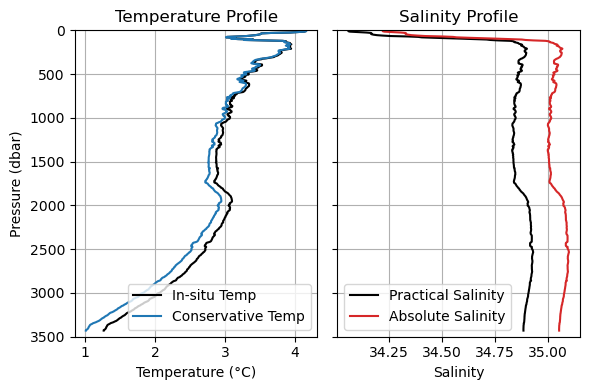

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(6, 4), sharey=True)

# Temperature
axes[0].plot(t, p, label='In-situ Temp', color='k')
axes[0].plot(CT, p, label='Conservative Temp', color='tab:blue')
axes[0].set_ylim(3500,0)
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Pressure (dbar)')
axes[0].set_title('Temperature Profile')
axes[0].legend()
axes[0].grid()

# Salinity
axes[1].plot(s, p, label='Practical Salinity', color='k')
axes[1].plot(SA, p, label='Absolute Salinity', color='tab:red')
axes[1].set_xlabel('Salinity')
axes[1].set_title('Salinity Profile')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [31]:
# interpolate to 1 dbar
# p_interp = _build_p_grid(p, p[-1], 1)
p_interp = np.arange(0., p[-1] + 1, 1)

sa_i = np.interp(p_interp, p, SA)
ct_i = np.interp(p_interp, p, CT)

In [33]:
# plt.plot(sa_i, p_interp)
# plt.plot(SA, p)

In [35]:
# compute in situ density
rho = gsw.rho(sa_i, ct_i, p_interp)  # kg/m3

# compute specific volume of example profile
alpha = 1.0 / rho # m3/kg

# compute reference specific volume (standard seawater)
s_ref_exact = gsw.SR_from_SP(35)
s_ref = np.full_like(p_interp, s_ref_exact)
t_ref  = np.zeros_like(p_interp)

rho_ref = gsw.rho(s_ref, t_ref, p_interp)
alpha_ref = 1.0 / rho_ref

# compute specific volume anomaly
delta = alpha - alpha_ref
# print(delta)

In [37]:
# gsw.specvol_anom_standard(SA,CT,p)

In [39]:
# convert pressure to Pa
p_pa = p_interp * 1e4

# cumulative trapezoidal integration
dyn_height_manual = cumulative_trapezoid(delta, p_pa, initial=0)

# convert to meters
dyn_height_manual_m = dyn_height_manual / 9.7963

print(dyn_height_manual_m[-1])

1.3701919526519328


In [41]:
# using the gsw package
dyn_height_gsw = gsw.geo_strf_dyn_height(sa_i, ct_i, p_interp, p_ref=p_interp[-1],interp_method='pchip')
dyn_height_gsw_m = dyn_height_gsw / 9.7963

dyn_height_gsw_m[0]

1.3701919526523207

In [43]:
print((dyn_height_manual_m[-1] - dyn_height_gsw_m[0])*100)

-3.879119248040297e-11


## Create a function to calculate the dynamic height

In [63]:
s = tmp_with_surface.salinity.values
t  = tmp_with_surface.temperature.values
p  = tmp_with_surface.pressure.values

# calculate conservative temperature and absolute salinity
SA = gsw.SA_from_SP(s, p, tmp_with_surface.longitude.values, tmp_with_surface.latitude.values)
CT = gsw.CT_from_t(SA, t, p)

In [93]:
def _specvol_anom_manual(SA, CT, p):
    """
    Manually calculate specific volume anomaly.
    delta = 1/rho(SA, CT, p) - 1/rho(SSO, 0, p)
    where SSO = gsw.SR_from_SP(35)
    """
    # In situ specific volume
    rho     = gsw.rho(SA, CT, p)
    alpha   = 1.0 / rho

    # Reference specific volume (standard seawater)
    s_ref    = np.full_like(p, gsw.SR_from_SP(35), dtype=float)
    t_ref    = np.zeros_like(p, dtype=float)
    rho_ref  = gsw.rho(s_ref, t_ref, p)
    alpha_ref = 1.0 / rho_ref

    return alpha - alpha_ref


def geo_strf_dyn_height(SA, CT, p, p_ref):
    """
    Calculate dynamic height anomaly as the integral of specific volume
    anomaly from pressure p to reference pressure p_ref.
    
    Parameters
    ----------
    SA : xr.DataArray - Absolute Salinity (g/kg), dims (depth, profile)
    CT : xr.DataArray - Conservative Temperature (deg C), dims (depth, profile)
    p  : xr.DataArray or np.ndarray - sea pressure (dbar), dims (depth,) or (depth, profile)
    p_ref : float - reference pressure (dbar)
    
    Returns
    -------
    xr.DataArray - dynamic height anomaly (m^2/s^2), dims (depth, profile)
    """
    
    # ── 1. Validate p_ref ────────────────────────────────────────────────────
    p_ref = float(np.unique(p_ref).item())
    if p_ref < 0:
        raise ValueError("p_ref must be positive")

    # ── 2. Broadcast p to match SA/CT if 1D ─────────────────────────────────
    # make sure p is float not int
    p = p.astype(float)
    
    if isinstance(p, xr.DataArray):
        p_vals = p.values
    else:
        p_vals = np.asarray(p)

    SA_vals = SA.values if isinstance(SA, xr.DataArray) else np.asarray(SA)
    CT_vals = CT.values if isinstance(CT, xr.DataArray) else np.asarray(CT)

    # Ensure 2D (depth x profile)
    if SA_vals.ndim == 1:
        SA_vals = SA_vals[:, np.newaxis]
        CT_vals = CT_vals[:, np.newaxis]
    if p_vals.ndim == 1:
        p_vals = np.tile(p_vals[:, np.newaxis], (1, SA_vals.shape[1]))

    mp, np_ = SA_vals.shape
    db2Pa = 1e4
    max_dp_i = 1.0  # maximum pressure increment (dbar)

    # ── 3. NaN mask ──────────────────────────────────────────────────────────
    nan_mask = np.isnan(SA_vals) | np.isnan(CT_vals) | np.isnan(p_vals)
    SA_vals[nan_mask] = np.nan
    CT_vals[nan_mask] = np.nan
    p_vals[nan_mask]  = np.nan

    # SA must be non-negative
    SA_vals = np.where(SA_vals < 0, 0, SA_vals)

    # ── 4. Check pressure is monotonically increasing ────────────────────────
    d_p = np.diff(p_vals, axis=0)
    if np.any(d_p[~np.isnan(d_p)] <= 0):
        raise ValueError("Pressure must be monotonically increasing")

    if np.nanmax(p_vals) < p_ref:
        raise ValueError("p_ref is deeper than all bottles")

    # ── 5. Identify problem profiles ─────────────────────────────────────────
    has_large_gap  = np.any(d_p > max_dp_i, axis=0)
    starts_at_zero = p_vals[0, :] == 0
    has_p_ref      = np.any(p_vals == p_ref, axis=0)

    needs_interp = has_large_gap | ~starts_at_zero | ~has_p_ref

    # ── 6. Output array ──────────────────────────────────────────────────────
    geo_strf = np.full(SA_vals.shape, np.nan)

    # ── 7. Fast path: perfect profiles ───────────────────────────────────────
    perfect = np.where(~needs_interp)[0]
    if len(perfect) > 0:
        SA_p = SA_vals[:, perfect]
        CT_p = CT_vals[:, perfect]
        p_p  = p_vals[:, perfect]

        B     = _specvol_anom_manual(SA_p, CT_p, p_p)          # ← manual
        B_av  = np.zeros_like(B)
        B_av[1:, :] = 0.5 * (B[:-1, :] + B[1:, :])

        dp         = np.zeros_like(p_p)
        dp[1:, :]  = np.diff(p_p, axis=0)
        D          = B_av * dp * db2Pa

        dyn_h0     = -np.cumsum(D, axis=0)

        p_ref_idx  = np.where(p_p[:, 0] == p_ref)[0][0]
        geo_strf[:, perfect] = dyn_h0 - dyn_h0[p_ref_idx, :]

    # ── 8. Slow path: profiles needing interpolation ─────────────────────────
    interp_profiles = np.where(needs_interp)[0]
    for iprof in interp_profiles:
        sa_col = SA_vals[:, iprof]
        ct_col = CT_vals[:, iprof]
        p_col  = p_vals[:, iprof]

        valid  = ~np.isnan(sa_col + ct_col + p_col)
        if valid.sum() < 2:
            continue
        sa_v = sa_col[valid]
        ct_v = ct_col[valid]
        p_v  = p_col[valid]

        if p_v.max() < p_ref:
            continue

        # ── 8a. Build fine pressure grid ─────────────────────────────────────
        p_fine = _build_p_grid(p_v, p_ref, max_dp_i)

        # ── 8b. Interpolate SA and CT onto fine grid ──────────────────────────
        sa_i = np.interp(p_fine, p_v, sa_v)
        ct_i = np.interp(p_fine, p_v, ct_v)

        # ── 8c. Compute specific volume anomaly and integrate ─────────────────
        B_i    = _specvol_anom_manual(sa_i, ct_i, p_fine)      # ← manual
        B_i_av = 0.5 * (B_i[:-1] + B_i[1:])
        D_i    = B_i_av * np.diff(p_fine) * db2Pa

        dyn_h0_i     = np.zeros(len(p_fine))
        dyn_h0_i[1:] = -np.cumsum(D_i)

        # ── 8d. Subtract value at p_ref ───────────────────────────────────────
        p_ref_idx_i = np.argmin(np.abs(p_fine - p_ref))
        dyn_h_i     = dyn_h0_i - dyn_h0_i[p_ref_idx_i]

        # ── 8e. Map back to original bottle pressures ─────────────────────────
        orig_indices = np.where(valid)[0]
        for k, p_orig in zip(orig_indices, p_v):
            idx_fine = np.argmin(np.abs(p_fine - p_orig))
            geo_strf[k, iprof] = dyn_h_i[idx_fine]

    # ── 9. Wrap in xarray and return ─────────────────────────────────────────
    if isinstance(SA, xr.DataArray):
        return xr.DataArray(
            geo_strf,
            coords=SA.coords,
            dims=SA.dims,
            attrs={"units": "m^2/s^2", "long_name": "dynamic height anomaly"}
        )
    return geo_strf

def _build_p_grid(p_v, p_ref, max_dp_i):
    """
    Build a fine pressure grid at <= max_dp_i resolution,
    ensuring p=0 and p_ref are included.
    """
    segments = []

    # Start from 0 if profile doesn't
    p_start = 0.0 if p_v[0] > 0 else p_v[0]
    all_p   = np.concatenate([[p_start], p_v])

    # Ensure p_ref is in the breakpoints
    if p_ref not in all_p and p_v.min() <= p_ref <= p_v.max():
        insert_idx = np.searchsorted(all_p, p_ref)
        all_p      = np.insert(all_p, insert_idx, p_ref)

    for i in range(len(all_p) - 1):
        p_lo, p_hi = all_p[i], all_p[i + 1]
        n_steps    = int(np.ceil((p_hi - p_lo) / max_dp_i))
        seg        = np.linspace(p_lo, p_hi, n_steps + 1)
        segments.append(seg if i == 0 else seg[1:])  # avoid duplicates

    return np.concatenate(segments)

In [95]:
p_ref = p[-1]

In [97]:
dyn_height_tmp = geo_strf_dyn_height(SA, CT, p, p_ref)

In [99]:
dyn_height_tmp[0][0] / 9.7963

1.3701919526519328

### Now create a version that takes a density profile as the input

In [102]:
def geo_strf_dyn_height_from_rho(rho, p, p_ref):
    """
    Calculate dynamic height anomaly from in situ density profiles.
    
    Parameters
    ----------
    rho   : xr.DataArray or np.ndarray - in situ density (kg/m3), dims (depth,) or (depth, profile)
    p     : xr.DataArray or np.ndarray - sea pressure (dbar), dims (depth,) or (depth, profile)
    p_ref : float - reference pressure (dbar)
    
    Returns
    -------
    xr.DataArray or np.ndarray - dynamic height anomaly (m^2/s^2), dims (depth, profile)
    """

    # ── 1. Validate p_ref ────────────────────────────────────────────────────
    p_ref = float(np.unique(p_ref).item())
    if p_ref < 0:
        raise ValueError("p_ref must be positive")

    # ── 2. Extract values ────────────────────────────────────────────────────
    rho_vals = rho.values if isinstance(rho, xr.DataArray) else np.asarray(rho, dtype=float)
    p_vals   = p.values   if isinstance(p,   xr.DataArray) else np.asarray(p,   dtype=float)

    # Ensure 2D (depth x profile)
    if rho_vals.ndim == 1:
        rho_vals = rho_vals[:, np.newaxis]
    if p_vals.ndim == 1:
        p_vals = np.tile(p_vals[:, np.newaxis], (1, rho_vals.shape[1]))

    db2Pa    = 1e4
    max_dp_i = 1.0

    # ── 3. Check pressure is monotonically increasing ────────────────────────
    d_p = np.diff(p_vals, axis=0)
    if np.any(d_p[~np.isnan(d_p)] <= 0):
        raise ValueError("Pressure must be monotonically increasing")

    if np.nanmax(p_vals) < p_ref:
        raise ValueError("p_ref is deeper than all bottles")

    # ── 4. Compute specific volume anomaly ───────────────────────────────────
    alpha     = 1.0 / rho_vals

    s_ref     = np.full_like(p_vals, gsw.SR_from_SP(35), dtype=float)
    t_ref     = np.zeros_like(p_vals, dtype=float)
    alpha_ref = 1.0 / gsw.rho(s_ref, t_ref, p_vals)

    delta = alpha - alpha_ref

    # ── 5. Identify problem profiles ─────────────────────────────────────────
    has_large_gap  = np.any(d_p > max_dp_i, axis=0)
    starts_at_zero = p_vals[0, :] == 0
    has_p_ref      = np.any(p_vals == p_ref, axis=0)
    needs_interp   = has_large_gap | ~starts_at_zero | ~has_p_ref

    # ── 6. Output array ──────────────────────────────────────────────────────
    geo_strf = np.full(rho_vals.shape, np.nan)

    # ── 7. Fast path: perfect profiles ───────────────────────────────────────
    perfect = np.where(~needs_interp)[0]
    if len(perfect) > 0:
        B    = delta[:, perfect]
        p_p  = p_vals[:, perfect]

        B_av = np.zeros_like(B)
        B_av[1:, :] = 0.5 * (B[:-1, :] + B[1:, :])

        dp       = np.zeros_like(p_p)
        dp[1:, :] = np.diff(p_p, axis=0)
        D        = B_av * dp * db2Pa

        dyn_h0   = -np.cumsum(D, axis=0)

        p_ref_idx = np.where(p_p[:, 0] == p_ref)[0][0]
        geo_strf[:, perfect] = dyn_h0 - dyn_h0[p_ref_idx, :]

    # ── 8. Slow path: profiles needing interpolation ─────────────────────────
    interp_profiles = np.where(needs_interp)[0]
    for iprof in interp_profiles:
        rho_col = rho_vals[:, iprof]
        p_col   = p_vals[:,   iprof]

        valid = ~np.isnan(rho_col + p_col)
        if valid.sum() < 2:
            continue
        rho_v = rho_col[valid]
        p_v   = p_col[valid]

        if p_v.max() < p_ref:
            continue

        # ── 8a. Build fine pressure grid ─────────────────────────────────────
        p_fine = _build_p_grid(p_v, p_ref, max_dp_i)

        # ── 8b. Interpolate density onto fine grid ────────────────────────────
        rho_i = np.interp(p_fine, p_v, rho_v)

        # ── 8c. Compute specific volume anomaly ───────────────────────────────
        alpha_i     = 1.0 / rho_i
        s_ref_i     = np.full_like(p_fine, gsw.SR_from_SP(35), dtype=float)
        t_ref_i     = np.zeros_like(p_fine, dtype=float)
        alpha_ref_i = 1.0 / gsw.rho(s_ref_i, t_ref_i, p_fine)
        B_i         = alpha_i - alpha_ref_i

        # ── 8d. Integrate ─────────────────────────────────────────────────────
        B_i_av       = 0.5 * (B_i[:-1] + B_i[1:])
        D_i          = B_i_av * np.diff(p_fine) * db2Pa
        dyn_h0_i     = np.zeros(len(p_fine))
        dyn_h0_i[1:] = -np.cumsum(D_i)

        # ── 8e. Subtract value at p_ref ───────────────────────────────────────
        p_ref_idx_i = np.argmin(np.abs(p_fine - p_ref))
        dyn_h_i     = dyn_h0_i - dyn_h0_i[p_ref_idx_i]

        # ── 8f. Map back to original bottle pressures ─────────────────────────
        orig_indices = np.where(valid)[0]
        for k, p_orig in zip(orig_indices, p_v):
            idx_fine = np.argmin(np.abs(p_fine - p_orig))
            geo_strf[k, iprof] = dyn_h_i[idx_fine]

    # ── 9. Wrap in xarray and return ─────────────────────────────────────────
    if isinstance(rho, xr.DataArray):
        return xr.DataArray(
            geo_strf,
            coords=rho.coords,
            dims=rho.dims,
            attrs={"units": "m^2/s^2", "long_name": "dynamic height anomaly"}
        )
    return geo_strf

In [104]:
s = tmp_with_surface.salinity.values
t  = tmp_with_surface.temperature.values
p  = tmp_with_surface.pressure.values

# calculate conservative temperature and absolute salinity
SA = gsw.SA_from_SP(s, p, tmp_with_surface.longitude.values, tmp_with_surface.latitude.values)
CT = gsw.CT_from_t(SA, t, p)

rho = gsw.rho(SA, CT, p)

In [114]:
dyn_height_from_rho = geo_strf_dyn_height_from_rho(rho, p, p[-1])

In [116]:
dyn_height_from_rho[0][0] / 9.7963

1.3701946789309964